<a href="https://colab.research.google.com/github/sofiiamyshelova-prog/python_for_ds_tasks/blob/main/Copy_of_HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics

df = pd.read_csv('marketing_campaign.csv', sep='\t')

print("Кількість рядків:", df.shape[0])
print("Кількість колонок:", df.shape[1])
print("\nТипи даних та кількість непропущених значень:")
df.info()
print("\nКількість пропущених значень:")
print(df.isnull().sum())

Кількість рядків: 2240
Кількість колонок: 29

Типи даних та кількість непропущених значень:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [2]:
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)

#порожні Income - 24 значення. заповнюю медіаною.
#не середнім, бо в ЗП часто бувають викиди - кілька дуже заможних клієнтів, які сильно вплинуть на загальну картину
#не видаляю ці значення, бо вони можуть повпливати на кластери

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [3]:
# категоріальні колонки 'Education', 'Marital_Status' кодуємо як в One-Hot Encoding, так як категорій небагато
# закодовувати числами не варто, щоб не створити порядковості, якої не повинно існувати

df = pd.get_dummies(
    df,
    columns=['Education', 'Marital_Status'],
    dtype=int
)

df.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,04-09-2012,58,635,88,546,...,0,0,0,0,0,0,1,0,0,0
1,2174,1954,46344.0,1,1,08-03-2014,38,11,1,6,...,0,0,0,0,0,0,1,0,0,0
2,4141,1965,71613.0,0,0,21-08-2013,26,426,49,127,...,0,0,0,0,0,0,0,1,0,0
3,6182,1984,26646.0,1,0,10-02-2014,26,11,4,20,...,0,0,0,0,0,0,0,1,0,0
4,5324,1981,58293.0,1,0,19-01-2014,94,173,43,118,...,0,1,0,0,0,1,0,0,0,0


In [4]:
# Перетворюємо дату на кількість днів з моменту реєстрації клієнта до найпізнішої реєстрації.
# таким чином встановиться порядок "стаж" клієнта в компанії
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    format='%d-%m-%Y'
)

reference_date = df['Dt_Customer'].max()

df['Customer_Since_Days'] = (
    reference_date - df['Dt_Customer']
).dt.days

df = df.drop(columns=['Dt_Customer'])

df.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Customer_Since_Days
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,0,1,0,0,0,663
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,1,0,0,0,113
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,0,1,0,0,312
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,0,1,0,0,139
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,1,0,0,0,1,0,0,0,0,161


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#видаляємо ідентифікатор. він не впливає на кластери
X = df.drop(columns=['ID'])


kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

#присвоюємо номери кластерів
df['Cluster'] = clusters

silhouette = silhouette_score(X, clusters)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.5981911827694943


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [6]:
import plotly.express as px

   # Загальна кількість покупок
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

# Загальні витрати
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)


fig = px.scatter_3d(
    df,
    x='Income',
    y='Total_Purchases',
    z='Total_Spending',
    color='Cluster',
    title='Customer Clusters: Income, Purchases and Spending',
    labels={
        'Income': 'Income',
        'Total_Purchases': 'Total Purchases',
        'Total_Spending': 'Total Spending',
        'Cluster': 'Cluster'
    },
    opacity=0.7
)

fig.show()

In [7]:
fig = px.scatter(
    df,
    x='Income',
    y='Total_Spending',
    color='Cluster',
    title='Customer Clusters: Income vs Total Spending',
    labels={
        'Income': 'Income',
        'Total_Spending': 'Total Spending',
        'Cluster': 'Cluster'
    },
    opacity=0.7
)

fig.show()

на графіках видно, що кластери залежать від доходу, але не залежать від витрат. Думаю, що треба масштабувати income, бо він має суттєво інші значення, ніж інші показники, тому сильно впливає на кластери і вони стають неінформативними

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

#присвоюємо номери кластерів
df['Cluster_scaler'] = clusters

silhouette = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.10818131488916809


In [9]:
fig = px.scatter(
    df,
    x='Income',
    y='Total_Spending',
    color='Cluster_scaler',
    title='Customer Clusters: Income vs Total Spending',
    labels={
        'Income': 'Income',
        'Total_Spending': 'Total Spending',
        'Cluster_scaler': 'Cluster_scaler'
    },
    opacity=0.7
)

fig.show()

Silhouette Score: 0.14, був 0.6

Тобто гірше розподілив дані по кластерам. Кластери не мають чітких кордонів.

На графіку виглядає так, ніби зараз на кластери впливають витрати більше, ніж дохід. Але кластери все ще не мають чіткого розмежування.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [10]:
Q1_income = df['Income'].quantile(0.25)
Q3_income = df['Income'].quantile(0.75)

IQR_income = Q3_income - Q1_income

lower_income = Q1_income - 1.5 * IQR_income
upper_income = Q3_income + 1.5 * IQR_income

outliers_income = df[
    (df['Income'] < lower_income) |
    (df['Income'] > upper_income)
]

print("Кількість викидів Income:", len(outliers_income))

outliers_income['Income']

Кількість викидів Income: 8


,Income
164,157243.0
617,162397.0
655,153924.0
687,160803.0
1300,157733.0
1653,157146.0
2132,156924.0
2233,666666.0


In [11]:
Q1_spending = df['Total_Spending'].quantile(0.25)
Q3_spending = df['Total_Spending'].quantile(0.75)

IQR_spending = Q3_spending - Q1_spending

lower_spending = Q1_spending - 1.5 * IQR_spending
upper_spending = Q3_spending + 1.5 * IQR_spending

outliers_spending = df[
    (df['Total_Spending'] < lower_spending) |
    (df['Total_Spending'] > upper_spending)
]

print("Кількість викидів Total Spending:", len(outliers_spending))

outliers_spending['Total_Spending']

Кількість викидів Total Spending: 3


,Total_Spending
1179,2525
1492,2524
1572,2525


In [12]:
df_clean = df[
    (df['Income'] >= lower_income) &
    (df['Income'] <= upper_income) &
    (df['Total_Spending'] >= lower_spending) &
    (df['Total_Spending'] <= upper_spending)
].copy()

print("Розмір до очищення:", df.shape)
print("Розмір після очищення:", df_clean.shape)

Розмір до очищення: (2240, 44)
Розмір після очищення: (2229, 44)


In [13]:
X = df_clean.drop(
    columns=['ID', 'Cluster','Cluster_scaler'],
    errors='ignore'
)

# Масштабування
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Додаємо кластери
df_clean['Cluster'] = clusters

# Silhouette Score
silhouette = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", silhouette)

fig = px.scatter(
    df_clean,
    x='Income',
    y='Total_Spending',
    color='Cluster',
    title='Customer Clusters: Income vs Total Spending',
    labels={
        'Income': 'Income',
        'Total_Spending': 'Total Spending',
        'Cluster': 'Cluster'
    },
    opacity=0.7
)

fig.show()

Silhouette Score: 0.1302981890049554


Silhouette Score: 0.13

Видалення викидів за доходами та витратами не покращило оцінку.

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

In [14]:
inertias = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)




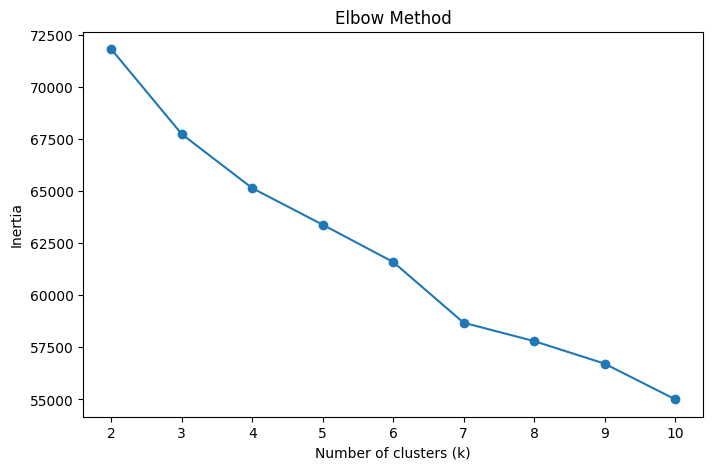

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker='o')

plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.xticks(k_values)

plt.show()

In [25]:
optimal_k = 3

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters_final = kmeans_final.fit_predict(X_scaled)

df_clean['Cluster'] = clusters_final

final_silhouette = silhouette_score(
    X_scaled,
    clusters_final
)

print(
    f"Final Silhouette Score: {final_silhouette:.4f}"
)

Final Silhouette Score: 0.1303


In [26]:
import plotly.express as px

fig = px.scatter(
    df_clean,
    x='Income',
    y='Total_Spending',
    color='Cluster',
    title=f'Customer Clusters (k = {optimal_k})',
    labels={
        'Income': 'Income',
        'Total_Spending': 'Total Spending',
        'Cluster': 'Cluster'
    },
    opacity=0.7
)

fig.show()

За оцінками оптимальне к=2, але візуально мені здається більш вдалим к=3

працюю на масштабованих даних, бо порядки ознак сильно різняться від одиниць до десятків тисяч

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

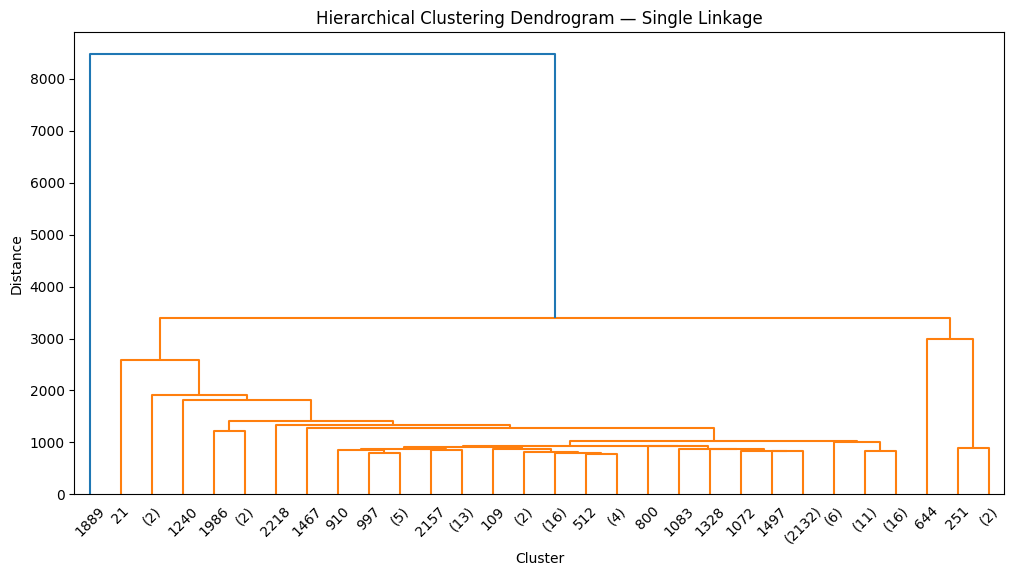

In [27]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

X_hier = df_clean.drop(
    columns=['ID', 'Cluster'],
    errors='ignore'
)

Z = linkage(
    X_hier,
    method='single'
)

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30
)

plt.title('Hierarchical Clustering Dendrogram — Single Linkage')
plt.xlabel('Cluster')
plt.ylabel('Distance')

plt.show()

In [30]:
clusters_2 = fcluster(
    Z,
    t=2,
    criterion='maxclust'
)

df_clean['Cluster_2'] = clusters_2

fig = px.scatter(
    df_clean,
    x='Income',
    y='Total_Spending',
    color='Cluster_2',
    title='Hierarchical Clustering — 2 Clusters',
    labels={
        'Income': 'Income',
        'Total_Spending': 'Total Spending',
        'Cluster_2': 'Cluster'
    },
    opacity=0.7
)

fig.show()

In [31]:
df_clean['Cluster_2'].value_counts()

,count
Cluster_2,
1,2228
2,1


In [33]:
clusters_3 = fcluster(
    Z,
    t=3,
    criterion='maxclust'
)

df_clean['Cluster_3'] = clusters_3

fig = px.scatter(
    df_clean,
    x='Income',
    y='Total_Spending',
    color='Cluster_3',
    title='Hierarchical Clustering — 3 Clusters',
    labels={
        'Income': 'Income',
        'Total_Spending': 'Total Spending',
        'Cluster_3': 'Cluster'
    },
    opacity=0.7
)

fig.show()

In [34]:
df_clean['Cluster_3'].value_counts()

,count
Cluster_3,
1,2224
2,4
3,1


маємо один великий кластер, бо всі точки приєднуються одна до одної, а ізольовані утворюють маленькі кластери

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [35]:
from sklearn.cluster import DBSCAN

X = df_clean.drop(
    columns=['ID', 'Cluster', 'Cluster_2', 'Cluster_3'],
    errors='ignore'
)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


dbscan = DBSCAN(eps=1.5, min_samples=5)

clusters_dbscan = dbscan.fit_predict(X_scaled)

df_clean['Cluster_DBSCAN'] = clusters_dbscan

print(df_clean['Cluster_DBSCAN'].value_counts())

Cluster_DBSCAN
-1     1989
 4       61
 0       40
 2       21
 8       15
 6       15
 3       10
 14       9
 1        8
 11       8
 12       8
 5        7
 10       6
 16       6
 13       6
 15       5
 7        5
 17       5
 9        5
Name: count, dtype: int64


In [36]:
mask = clusters_dbscan != -1

silhouette = silhouette_score(
    X_scaled[mask],
    clusters_dbscan[mask]
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.3823715357466798


In [37]:
n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)

print("Кількість кластерів:", n_clusters)

Кількість кластерів: 18


In [38]:
fig = px.scatter(
    df_clean,
    x='Income',
    y='Total_Spending',
    color='Cluster_DBSCAN',
    title='DBSCAN: Income vs Total Spending',
    labels={
        'Income': 'Income',
        'Total_Spending': 'Total Spending',
        'Cluster_DBSCAN': 'Cluster'
    },
    opacity=0.7
)

fig.show()

Взагалі шось не те

можливо ці дані неможливо кластеризувати, бо наявними методами не виходить гарної явної кластеризації.

остання кластеризація не була корисною